In [2]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sp500_px = pd.read_csv('data/sp500_data.csv.gz')
sp500_px.set_index("Unnamed: 0", inplace=True)
sp500_px

,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,ALTR,ADI,AVGO,BRCM,FSLR,INTC,LLTC,MCHP,MU,NVDA,QRVO,QCOM,SWKS,TXN,XLNX,AAPL,HPQ,EA,SNDK,STX,WDC,TEL,HRS,MSI,ACN,AMAT,KLAC,LRCX,ADBE,ADSK,ORCL,...,ENDP,LLY,MNK,MRK,MYL,PRGO,PFE,ZTS,ABT,A,BCR,BAX,BDX,BSX,EW,HSP,ISRG,JNJ,MDT,PKI,STJ,SYK,TMO,VAR,ZBH,BMY,CAH,CERN,ESRX,MCK,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1993-01-29,0.000000,0.060124,-0.022100,0.000000,0.000000,0.018897,0.007368,0.092165,0.259140,-0.007105,-0.015785,0.000000,0.000000,0.000000,-0.050488,-0.089870,0.000000,0.037021,0.000000,0.000000,-0.044718,-0.041262,0.060179,0.033152,-0.024235,0.045586,0.125000,0.000000,0.000000,0.118103,0.000000,0.016412,-1.842719,0.000000,-0.012867,0.079940,0.246706,-0.044884,0.057267,-0.005776,...,0.000000,-0.077535,0.000000,-0.028797,0.166355,-0.577943,0.066591,0.000000,0.045961,0.000000,-0.326659,0.000000,-0.033363,0.062500,0.000000,0.000000,0.000000,0.018827,0.006047,0.000000,0.187132,0.276317,-0.124187,0.037430,0.000000,0.038546,0.060142,0.031260,0.001950,0.000000,0.000000,0.000000,0.347160,0.000000,0.041670,0.000000,0.015564,1.750000,0.125000,0.000000
1993-02-01,0.000000,-0.180389,0.027621,0.000000,0.000000,0.018889,0.018425,0.115207,-0.100775,0.063893,-0.015793,0.000000,0.000000,0.000000,0.095367,0.044935,0.000000,0.037020,0.000000,0.000000,0.006387,-0.041252,0.102317,0.099446,0.064618,0.072942,0.093750,0.000000,0.000000,0.000000,0.000000,-0.032829,0.594428,0.000000,0.016077,0.019985,0.411170,0.134672,0.057267,0.025999,...,0.000000,-0.031014,0.000000,-0.172781,-0.066536,0.346766,-0.027745,0.000000,-0.045960,0.000000,-0.093331,0.018157,0.100076,0.031250,0.000000,0.000000,0.000000,-0.056481,-0.048392,0.041782,-0.074851,-0.027632,0.000000,-0.074859,0.000000,-0.038546,0.060142,0.101560,0.019530,0.000000,0.000000,0.000000,-0.231440,0.000000,0.000000,-0.010410,0.007782,1.250000,0.125000,0.000000
1993-02-02,0.000000,-0.120257,0.035900,0.000000,0.000000,-0.075573,0.029482,-0.023041,0.028796,-0.014192,0.047363,0.000000,0.000000,0.000000,0.000000,0.067402,0.000000,0.123402,0.000000,0.000000,0.035141,0.041252,-0.024066,0.016572,-0.016148,-0.045586,-0.062500,0.000000,0.000000,0.118103,0.000000,-0.032829,0.237767,0.000000,0.051450,0.000000,0.054828,0.082299,-0.042955,-0.011562,...,0.000000,-0.062028,0.000000,-0.143984,-0.066536,0.693532,-0.133183,0.000000,-0.153198,0.000000,-0.093331,-0.072626,0.000000,0.031250,0.000000,0.000000,0.000000,-0.018827,0.000000,0.208912,0.018711,-0.027632,0.000000,0.044923,0.000000,-0.115639,-0.030071,-0.015620,0.000000,0.000000,0.000000,0.000000,-0.115720,0.000000,0.000000,0.000000,-0.007792,-0.250000,0.000000,0.000000
1993-02-03,0.000000,0.060124,-0.024857,0.000000,0.000000,-0.151128,0.003689,-0.253454,-0.043190,-0.007105,0.205236,0.000000,0.000000,0.000000,-0.050495,0.022467,0.000000,-0.012340,0.000000,0.000000,0.006387,0.041252,-0.024073,0.049723,-0.032305,-0.091184,0.218750,0.000000,0.000000,0.059052,0.000000,0.049247,-0.118893,0.000000,0.000000,0.039970,-0.054828,-0.149639,0.057267,0.002884,...,0.000000,0.139564,0.000000,0.345561,0.133081,0.693532,0.022199,0.000000,0.168520,0.000000,0.093331,0.090783,0.044480,0.031250,0.000000,0.000000,0.000000,0.263578,0.030243,0.125347,0.187140,0.000000,0.124187,0.104805,0.000000,0.141333,0.000000,-0.011720,0.023440,0.000000,0.000000,0.000000,-0.086790,0.000000,0.041670,-0.041670,-0.038919,-0.500000,0.062500,0.000000
1993-02-04,0.000000,-0.360770,-0.060757,0.000000,0.000000,0.113350,-0.022114,0.069862,0.000000,-0.007096,-0.031570,0.000000,0.000000,0.000000,0.000000,0.022467,0.000000,-0.074041,0.000000,0.000000,0.051113,0.041252,-0.024073,-0.008290,-0.016157,-0.109414,0.093750,0.000000,0.000000,-0.118103,0.000000,0.000000,-0.237776,0.000000,-0.003219,-0.099925,-0.246706,0.000000,-0.157480,-0.017329,...,0.000000,0.000000,0.000000,-0.345561,-0.133073,-0.924709,-0.016648,0.000000,-0.061282,0.000000,0.186662,0.000000,-0.011123,-0.156250,0.00000

In [4]:
oil_px = sp500_px[['XOM', 'CVX']]
oil_px

,XOM,CVX
Unnamed: 0,,
1993-01-29,-0.016991,0.072921
1993-02-01,0.016991,0.102089
1993-02-02,0.084954,0.029168
1993-02-03,0.067964,0.058337
1993-02-04,0.034378,0.044272
...,...,...
2015-06-25,-0.919998,-1.110001
2015-06-26,0.029999,0.360000
2015-06-29,-0.230003,-0.809998


In [5]:
pcs = PCA(n_components=2)
pcs.fit(oil_px)
loadings = pd.DataFrame(pcs.components_, columns=oil_px.columns)
loadings

,XOM,CVX
0,0.664711,0.747101
1,0.747101,-0.664711


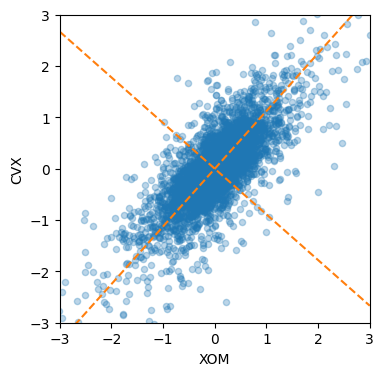

In [6]:
def abline(slope, intercept, ax):
 """Calculate coordinates of a line based on slope and intercept"""
 x_vals = np.array(ax.get_xlim())
 return (x_vals, intercept + slope * x_vals)
ax = oil_px.plot.scatter(x='XOM', y='CVX', alpha=0.3, figsize=(4, 4))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.plot(*abline(loadings.loc[0, 'CVX'] / loadings.loc[0, 'XOM'], 0, ax),
 '--', color='C1')
ax.plot(*abline(loadings.loc[1, 'CVX'] / loadings.loc[1, 'XOM'], 0, ax),
 '--', color='C1')

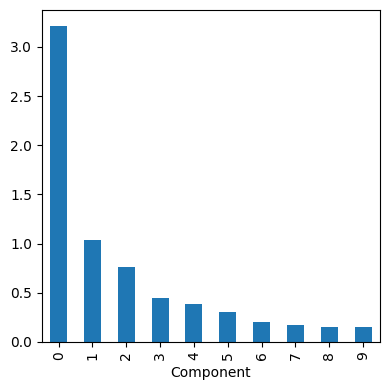

In [7]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
        'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])



top_sp = sp500_px.loc[pd.to_datetime(sp500_px.index) >= '2011-01-01', syms]

sp_pca = PCA()
sp_pca.fit(top_sp)

explained_variance = pd.DataFrame(sp_pca.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

plt.tight_layout()
plt.show()

In [8]:
sp500_px.columns

Index(['ADS', 'CA', 'MSFT', 'RHT', 'CTSH', 'CSC', 'EMC', 'IBM', 'XRX', 'ALTR',
       ...
       'WAT', 'ALXN', 'AMGN', 'BXLT', 'BIIB', 'CELG', 'GILD', 'REGN', 'VRTX',
       'HSIC'],
      dtype='object', length=517)

In [9]:
sp500_px.index

Index(['1993-01-29', '1993-02-01', '1993-02-02', '1993-02-03', '1993-02-04',
       '1993-02-05', '1993-02-08', '1993-02-09', '1993-02-10', '1993-02-11',
       ...
       '2015-06-18', '2015-06-19', '2015-06-22', '2015-06-23', '2015-06-24',
       '2015-06-25', '2015-06-26', '2015-06-29', '2015-06-30', '2015-07-01'],
      dtype='object', name='Unnamed: 0', length=5647)

In [10]:
top_sp

,AAPL,AXP,COP,COST,CSCO,CVX,HD,INTC,JPM,MSFT,SLB,TGT,USB,WFC,WMT,XOM
Unnamed: 0,,,,,,,,,,,,,,,,
2011-01-03,0.527368,0.093870,-0.336272,-0.240605,0.035704,0.240681,0.099184,-0.137211,0.512093,-0.061805,-0.325923,0.455646,-0.234866,0.250042,0.294839,0.736805
2011-01-04,-0.154321,-0.431788,-0.463161,-0.171859,0.008926,-0.584516,-0.541005,0.025726,0.335894,0.132440,-2.030049,-0.580720,-0.153566,0.000000,0.142951,0.168668
2011-01-05,0.597152,0.895406,-0.057104,-0.859307,0.169599,0.446985,-0.054099,-0.214392,0.689468,0.088294,1.536499,-0.482448,0.198732,0.857284,-0.303772,0.026631
2011-01-06,-0.132850,-0.612646,-0.463161,0.249200,0.035706,-0.919751,-0.189354,0.085757,0.070713,0.688689,-1.927614,-0.786210,-0.532962,0.000000,-0.312709,0.248558
2011-01-07,0.285820,-0.537242,-0.006350,-0.257788,0.098187,0.180511,-0.036064,-0.042878,-0.795539,-0.035317,0.931215,-0.089345,-0.171633,-0.651894,0.169758,0.337329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-25,-1.360001,-1.105863,-0.949997,-1.000000,-0.158775,-1.110001,-1.000000,-0.030000,-0.665647,-0.379997,-0.690003,0.080002,-0.238625,-0.580002,-0.589996,-0.919998
2015-06-26,-0.919998,-0.288920,0.029998,0.119996,-0.208393,0.360000,-0.169999,-0.490000,0.009930,-0.390004,0.279999,-0.409996,-0.020001,0.099999,0.160004,0.029999
2015-06-29,-0.930000,-1.414705,-0.410000,-1.319993,-0.446558,-0.809998,-1.019997,-0.310002,-0.476886,-0.670002,0.060006,-1.390007,-0.500000,-0.739998,-0.380005,-0.230003


In [11]:
loadings = pd.DataFrame(sp_pca.components_[0:5, :], 
                        columns=top_sp.columns)
loadings

,AAPL,AXP,COP,COST,CSCO,CVX,HD,INTC,JPM,MSFT,SLB,TGT,USB,WFC,WMT,XOM
0,0.300825,0.246332,0.261529,0.273634,0.064059,0.444490,0.207983,0.076956,0.196397,0.105012,0.481786,0.148833,0.116421,0.145684,0.122304,0.317952
1,0.505116,0.139426,-0.174212,0.416307,0.031939,-0.289373,0.278002,0.033898,0.040723,0.053954,-0.472494,0.228123,0.054796,0.047427,0.222889,-0.154192
2,0.786730,-0.135458,0.002367,-0.465862,0.007524,-0.082374,-0.166320,0.003518,-0.062261,-0.016248,0.194822,-0.160833,-0.048976,-0.041932,-0.175806,-0.090167
3,-0.120586,0.061814,-0.206026,0.092596,0.003904,-0.577665,0.162814,-0.001605,0.057687,-0.012558,0.680914,0.109895,0.016752,0.018614,0.058439,-0.295204
4,-0.111576,0.596666,0.005813,-0.555529,0.039860,-0.109016,0.185488,0.072047,0.385160,0.077135,-0.181332,0.055557,0.155440,0.216425,-0.091541,-0.013277


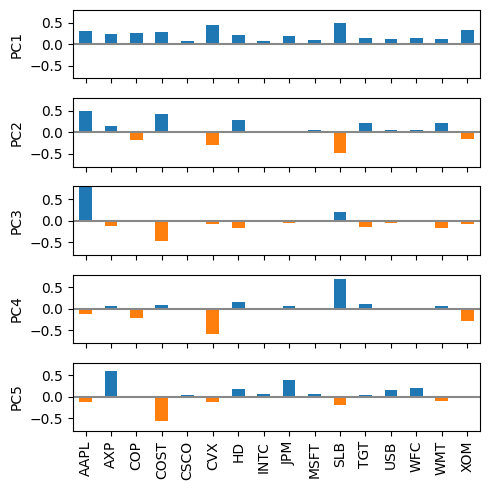

In [12]:
maxPC = 1.01 * loadings.loc[0:5, :].abs().to_numpy().max()

f, axes = plt.subplots(5, 1, figsize=(5, 5), sharex=True)

for i, ax in enumerate(axes):
    pc_loadings = loadings.loc[i, :]
    colors = ['C0' if l > 0 else 'C1' for l in pc_loadings]
    ax.axhline(color='#888888')
    pc_loadings.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'PC{i+1}')
    ax.set_ylim(-maxPC, maxPC)

plt.tight_layout()
plt.show()

In [13]:
import prince
from adjustText import adjust_text

housetasks = pd.read_csv("data/housetasks.csv", index_col=0)
housetasks


,Wife,Alternating,Husband,Jointly
Task,,,,
Laundry,156,14,2,4
Main_meal,124,20,5,4
Dinner,77,11,7,13
Breakfast,82,36,15,7
Tidying,53,11,1,57
Dishes,32,24,4,53
Shopping,33,23,9,55
Official,12,46,23,15
Driving,10,51,75,3


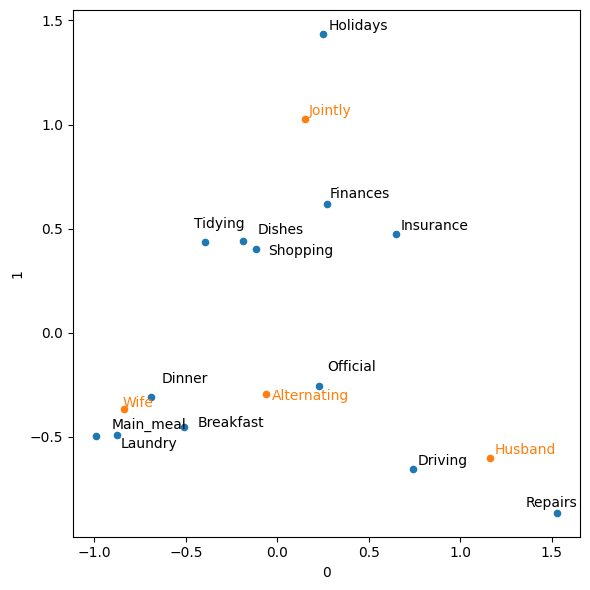

In [14]:
ca = prince.CA(n_components=2)
ca = ca.fit(housetasks)

ax = ca.row_coordinates(housetasks).plot.scatter(x=0, y=1, figsize=(6,6))
ca.column_coordinates(housetasks).plot.scatter(x=0, y=1, ax=ax, c='C1')
texts = []
for idx, row in ca.row_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx))
for idx, row in ca.column_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx, color='C1'))
adjust_text(texts, only_move={'points':'y', 'texts':'y'}) 
plt.tight_layout()
plt.show()

In [19]:
from sklearn.cluster import KMeans
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
kmeans = KMeans(n_clusters=4, n_init='auto').fit(df)
df['cluster'] = kmeans.labels_
df

,XOM,CVX,cluster
Unnamed: 0,,,
2011-01-03,0.736805,0.240681,3
2011-01-04,0.168668,-0.584516,0
2011-01-05,0.026631,0.446985,3
2011-01-06,0.248558,-0.919751,0
2011-01-07,0.337329,0.180511,3
...,...,...,...
2015-06-25,-0.919998,-1.110001,2
2015-06-26,0.029999,0.360000,3
2015-06-29,-0.230003,-0.809998,0


In [20]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['XOM', 'CVX'])
centers

,XOM,CVX
0,-0.330814,-0.574398
1,0.927032,1.346412
2,-1.144397,-1.757796
3,0.231540,0.316965


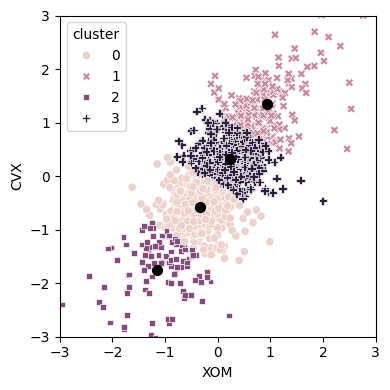

In [21]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.scatterplot(x='XOM', y='CVX', hue='cluster', style='cluster', 
                     ax=ax, data=df)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
centers.plot.scatter(x='XOM', y='CVX', ax=ax, s=50, color='black')

plt.tight_layout()
plt.show()

In [30]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP', 
               'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]
kmeans = KMeans(n_clusters=5, n_init='auto').fit(top_sp)

top_sp["cluster"] = kmeans.labels_

centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)

top_sp

,AAPL,AXP,COP,COST,CSCO,CVX,HD,INTC,JPM,MSFT,SLB,TGT,USB,WFC,WMT,XOM,cluster
Unnamed: 0,,,,,,,,,,,,,,,,,
2011-01-03,0.527368,0.093870,-0.336272,-0.240605,0.035704,0.240681,0.099184,-0.137211,0.512093,-0.061805,-0.325923,0.455646,-0.234866,0.250042,0.294839,0.736805,0
2011-01-04,-0.154321,-0.431788,-0.463161,-0.171859,0.008926,-0.584516,-0.541005,0.025726,0.335894,0.132440,-2.030049,-0.580720,-0.153566,0.000000,0.142951,0.168668,3
2011-01-05,0.597152,0.895406,-0.057104,-0.859307,0.169599,0.446985,-0.054099,-0.214392,0.689468,0.088294,1.536499,-0.482448,0.198732,0.857284,-0.303772,0.026631,2
2011-01-06,-0.132850,-0.612646,-0.463161,0.249200,0.035706,-0.919751,-0.189354,0.085757,0.070713,0.688689,-1.927614,-0.786210,-0.532962,0.000000,-0.312709,0.248558,3
2011-01-07,0.285820,-0.537242,-0.006350,-0.257788,0.098187,0.180511,-0.036064,-0.042878,-0.795539,-0.035317,0.931215,-0.089345,-0.171633,-0.651894,0.169758,0.337329,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-25,-1.360001,-1.105863,-0.949997,-1.000000,-0.158775,-1.110001,-1.000000,-0.030000,-0.665647,-0.379997,-0.690003,0.080002,-0.238625,-0.580002,-0.589996,-0.919998,1
2015-06-26,-0.919998,-0.288920,0.029998,0.119996,-0.208393,0.360000,-0.169999,-0.490000,0.009930,-0.390004,0.279999,-0.409996,-0.020001,0.099999,0.160004,0.029999,3
2015-06-29,-0.930000,-1.414705,-0.410000,-1.319993,-0.446558,-0.809998,-1.019997,-0.310002,-0.476886,-0.670002,0.060006,-1.390007,-0.500000,-0.739998,-0.380005,-0.230003,3


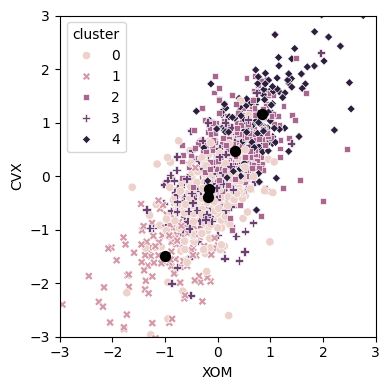

In [31]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.scatterplot(x='XOM', y='CVX', hue='cluster', style='cluster', 
                     ax=ax, data=top_sp)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
centers.plot.scatter(x='XOM', y='CVX', ax=ax, s=50, color='black')

plt.tight_layout()
plt.show()

In [32]:
from collections import Counter
print(Counter(kmeans.labels_))

Counter({np.int32(2): 354, np.int32(0): 272, np.int32(3): 224, np.int32(4): 155, np.int32(1): 126})


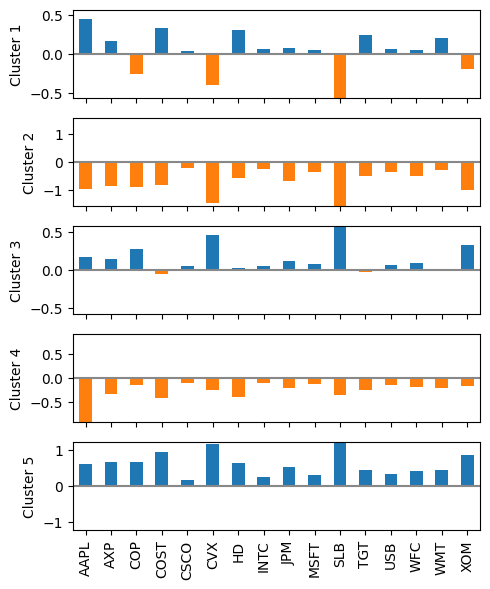

In [33]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)

f, axes = plt.subplots(5, 1, figsize=(5, 6), sharex=True)
for i, ax in enumerate(axes):
    center = centers.loc[i, :]
    maxPC = 1.01 * np.max(np.max(np.abs(center)))
    colors = ['C0' if l > 0 else 'C1' for l in center]
    ax.axhline(color='#888888')
    center.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'Cluster {i + 1}')
    ax.set_ylim(-maxPC, maxPC)

plt.tight_layout()
plt.show()

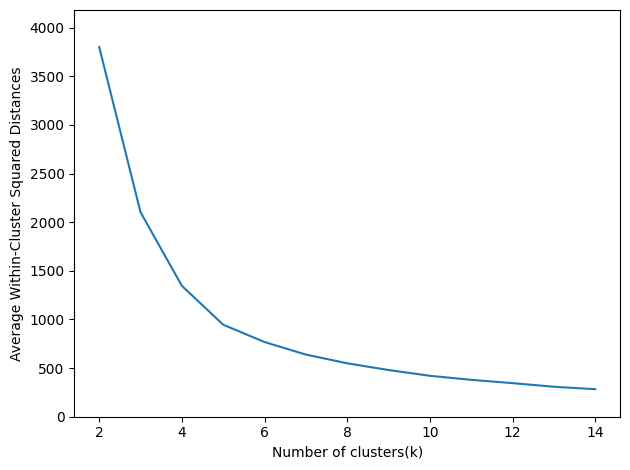

In [34]:
inertia = []
for n_clusters in range(2, 15):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto').fit(top_sp)
    inertia.append(kmeans.inertia_ / n_clusters)
inertias = pd.DataFrame({'n_clusters': range(2, 15), 'inertia': inertia})
ax = inertias.plot(x='n_clusters', y='inertia')
plt.xlabel('Number of clusters(k)')
plt.ylabel('Average Within-Cluster Squared Distances')
plt.ylim((0, 1.1 * inertias.inertia.max()))
ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

In [54]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

syms1 = ['AAPL', 'AMZN', 'AXP', 'COP', 'COST', 'CSCO', 'CVX', 'GOOGL', 'HD', 
         'INTC', 'JPM', 'MSFT', 'SLB', 'TGT', 'USB', 'WFC', 'WMT', 'XOM']
df = sp500_px.loc[sp500_px.index >= '2011-01-01', syms1].transpose()


Z = linkage(df, method='complete')
print(Z.shape)

(17, 4)


In [55]:
df

Unnamed: 0,2011-01-03,2011-01-04,2011-01-05,2011-01-06,2011-01-07,2011-01-10,2011-01-11,2011-01-12,2011-01-13,2011-01-14,2011-01-18,2011-01-19,2011-01-20,2011-01-21,2011-01-24,2011-01-25,2011-01-26,2011-01-27,2011-01-28,2011-01-31,2011-02-01,2011-02-02,2011-02-03,2011-02-04,2011-02-07,2011-02-08,2011-02-09,2011-02-10,2011-02-11,2011-02-14,2011-02-15,2011-02-16,2011-02-17,2011-02-18,2011-02-22,2011-02-23,2011-02-24,2011-02-25,2011-02-28,2011-03-01,...,2015-05-06,2015-05-07,2015-05-08,2015-05-11,2015-05-12,2015-05-13,2015-05-14,2015-05-15,2015-05-18,2015-05-19,2015-05-20,2015-05-21,2015-05-22,2015-05-26,2015-05-27,2015-05-28,2015-05-29,2015-06-01,2015-06-02,2015-06-03,2015-06-04,2015-06-05,2015-06-08,2015-06-09,2015-06-10,2015-06-11,2015-06-12,2015-06-15,2015-06-16,2015-06-17,2015-06-18,2015-06-19,2015-06-22,2015-06-23,2015-06-24,2015-06-25,2015-06-26,2015-06-29,2015-06-30,2015-07-01
AAPL,0.527368,-0.154321,0.597152,-0.132850,0.285820,0.485766,-0.434780,0.157012,0.069781,0.347552,1.493539,-1.276160,-0.503220,-0.946041,1.419738,0.680352,0.119427,-0.076492,-1.082911,0.472350,0.500533,-0.017447,-0.048310,0.383783,0.535419,0.203974,0.398542,-0.382439,0.281799,0.320717,0.095279,0.312658,0.140901,-1.093654,-0.475031,0.516632,-0.152970,0.389147,0.264356,-0.826614,...,-1.543548,0.490005,0.940003,-1.069999,0.270005,-0.140000,1.539993,-0.300003,1.809997,-0.619995,0.059998,1.319992,0.939987,-2.980011,1.699997,-0.080002,-0.949997,0.259994,0.100006,-0.540009,-0.220001,-0.850006,-1.099991,0.720001,0.960007,-0.589997,-1.020004,0.820000,0.569999,-0.419998,0.649994,-1.110001,0.120003,-0.450004,0.900002,-1.360001,-0.919998,-0.930000,-0.140000,-0.300004
AMZN,2.850006,-1.139999,3.319992,-0.639999,-2.390000,-0.360000,-1.080002,-1.279999,1.929993,3.250000,2.589996,-4.029999,-3.329986,-5.580002,-1.099991,1.199997,-2.119996,6.970001,-0.309998,-0.520005,1.589997,2.110001,0.210007,1.929993,0.279999,6.399994,2.150009,1.820008,3.690002,1.169998,0.300003,-3.150009,1.989991,-1.039993,-3.259995,-3.570007,0.889999,-1.709992,-0.620011,-4.089997,...,-2.329987,2.730011,2.940002,0.339996,-0.059998,-3.110016,2.829987,-2.000000,-0.760010,-3.160004,3.259979,3.630005,-3.919983,-0.730011,3.970001,-3.139984,2.000000,0.520019,0.919983,2.190002,-3.619995,-2.709992,-2.119995,2.520020,4.309998,0.679992,-1.329987,-3.989991,3.110016,-0.549987,9.090027,-5.339997,-0.709991,10.399994,-4.130005,2.029999,-3.660004,-5.120026,-0.110016,-1.959991
AXP,0.093870,-0.431788,0.895406,-0.612646,-0.537242,0.245056,0.056553,-0.414713,0.235633,1.244141,0.320461,0.037702,0.499540,0.226209,-0.245056,-0.065977,-0.424140,0.047126,-0.650345,-0.706898,0.056549,0.311037,-0.113107,0.273335,0.810578,1.149889,0.113107,0.857703,0.452415,0.094255,-0.292186,0.414717,-0.725749,-0.065976,-0.612643,-0.716326,0.263911,-0.056553,-0.150805,-0.518391,...,-0.846831,0.587805,0.089669,0.647571,-0.069739,0.358659,0.408476,-0.677466,-0.109591,0.986308,-0.448328,0.219181,0.408476,-0.926534,-0.338729,0.119548,-0.318807,-0.468249,0.727275,0.278954,-0.687430,-0.348694,-0.617691,0.288920,0.986315,-0.039844,-0.896646,0.249068,0.318807,0.677466,0.528023,-0.328765,0.567875,-0.079703,-0.199258,-1.105863,-0.288920,-1.414705,-0.449997,-0.239997
COP,-0.336272,-0.463161,-0.057104,-0.463161,-0.006350,0.095172,0.380682,0.038061,-0.704260,0.279170,0.107859,-0.323578,-0.183998,-0.139587,0.215721,-0.310894,0.767708,-0.012688,0.532959,0.107856,0.057105,0.298203,-0.063445,-0.222062,0.367989,-0.158617,-0.672533,-0.012691,1.084943,1.148390,-0.107856,0.551996,0.640108,0.428870,-0.640111,1.043369,-1.043379,-0.019203,0.377668,-0.300849,...,-0.721813,-0.899795,0.029663,-1.819377,0.108768,-0.405408,-0.118658,0.504285,0.286750,-0.622935,0.029999,0.450005,0.070000,-0.730000,-0.119999,0.330002,-0.020001,-0.849998,0.369999,-0.010002,-0.410000,0.280003,0.510002,-0.719998,0.109997,0.059998,-0.250000,0.189998,-0.009999,-0.790001,-0.220002,-0.200001,0.100002,0.489998,-0.299999,-0.949997,0.029998,-0.410000,-0.119999,-1.479999
COST,-0.240605,-0.171859,-0

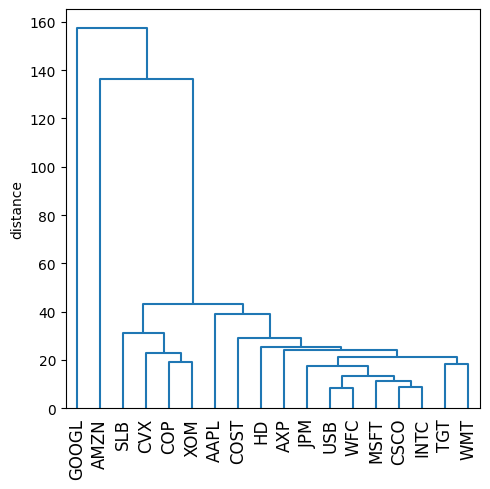

In [49]:
fig, ax = plt.subplots(figsize=(5, 5))
dendrogram(Z, labels=list(df.index), color_threshold=0)
plt.xticks(rotation=90)
ax.set_ylabel('distance')

plt.tight_layout()
plt.show()

In [50]:

memb = fcluster(Z, 4, criterion='maxclust')
memb = pd.Series(memb, index=df.index)
for key, item in memb.groupby(memb):
    print(f"{key} : {', '.join(item.index)}")

1 : COP, CVX, SLB, XOM
2 : AAPL, AXP, COST, CSCO, HD, INTC, JPM, MSFT, TGT, USB, WFC, WMT
3 : AMZN
4 : GOOGL


In [51]:
memb

AAPL     2
AMZN     3
AXP      2
COP      1
COST     2
CSCO     2
CVX      1
GOOGL    4
HD       2
INTC     2
JPM      2
MSFT     2
SLB      1
TGT      2
USB      2
WFC      2
WMT      2
XOM      1
dtype: int32

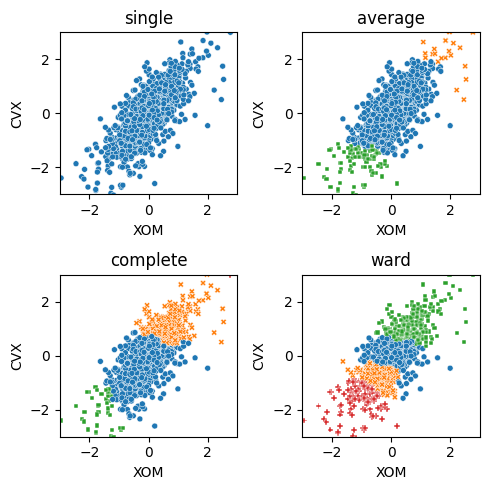

In [52]:
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
for i, method in enumerate(['single', 'average', 'complete', 'ward']):
    ax = axes[i // 2, i % 2]
    Z = linkage(df, method=method)
    colors = [f'C{c+1}' for c in fcluster(Z, 4, criterion='maxclust')]
    ax = sns.scatterplot(x='XOM', y='CVX', hue=colors, style=colors,
                         size=0.5, ax=ax, data=df, legend=False)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(method)

plt.tight_layout()
plt.show()

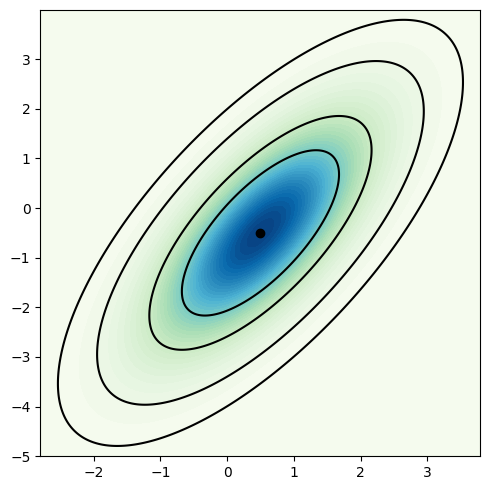

In [57]:
from scipy.stats import multivariate_normal
from matplotlib.cm import GnBu

mean = [0.5, -0.5]
cov = [[1, 1], [1, 2]]
probability = [.5, .75, .95, .99]
def probLevel(p):
    D = 1
    return (1 - p) / (2 * np.pi * D)
levels = [probLevel(p) for p in probability]

fig, ax = plt.subplots(figsize=(5, 5))

x, y = np.mgrid[-2.8:3.8:.01, -5:4:.01]
pos = np.empty(x.shape + (2,))
pos[:, :, 0] = x; pos[:, :, 1] = y
rv = multivariate_normal(mean, cov)


CS = ax.contourf(x, y, rv.pdf(pos), cmap=GnBu, levels=50)
ax.contour(CS, levels=levels, colors=['black'])
ax.plot(*mean, color='black', marker='o')


plt.tight_layout()
plt.show()